## 0. Purpose

This script converts the data into pd.dataframes which can be used to train the RF. Using the settings, over- and undersampling can be used to create a balanced dataset. The trained regions can also be chosen.

## 1.1 Import Packages


In [8]:
import xarray as xr
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold


## 1.2 Import functions

In [9]:
from plot_functions import *
from read_functions import *
from datahandling_functions import *
from analysis_functions import *

## 2. Convert Trainingdata to dataframe

### 2.1 Settings

These settings allow to quickly change the inputs for the Random forest.

### chosen_bands:

Here you can change the input bands, indices and texture variables.

### REGION_TRAIN_MODE

Here you can change the data used for training the random forest classifier.\
N22 = Northern Bavaria 2022\
N23 = Northern Bavaria 2023\
S20 = Southern Bavaria 2020\
S22 = Southern Bavaria 2022\
This input solely changes the training data.

### REGION_VAL_MODE

Here you can change the data used for validating the random forest classifer.\
If REGION_TRAIN_MODE equals REGION_VAL_MODE, a training/validation split of 70/30 is used.\
If all the data is used to train the model (REGION_TRAIN_MODE == ALL) and is used on one scene (e.g. N22), half of the N22 data is used for validation, half of the data is used for training. The option ALL for REGION_VAL_MODE is only provided if REGION_TRAIN_MODE is ALL as well.

### BALANCE_MODE

UNDERSAMPLING: undersamples the majority classes so that all classes have the same number of pixels/rows in the training data.\
OVERSAMPLING: oversamples the minority class.\
WEIGHTS: upsamples only "deadwood" class by a certain factor.\
NONE: samples 30.000 random pixels

### (OVERSAMPLE_NUMBER)

Only usable if BALANCE_MODE = OVERSAMPLING.\
OVERSAMPLE_NUMBER: the number to which the minority class is oversampled.\
The number of all valid pixels of all classes used with OVERSAMPLING is therefore 3*OVERSAMPLE_NUMBER.

### VAL_BALANCE

VAL_BALANCE decides how the validation/test-data is treated.\
NONE: unbalanced training data is used\
SAME: The validation data gets the same treatment as the training data, and is therefore balanced.


### PREDICTION_MODE
value: The random forests predicts a specific value, in this case, a class (1, 2 or 3).\
proba: The random forests predicts a probabilty for each class. This option can be used to make it "harder" for the model to predict the deadwood class.


### (PROBA_THRESHOLD)

PROBA_THRESHOLD: only useable if you used PREDICTION_MODE = proba.\
The threshold the deadwood class needs to reach to be classified.\
If the PROBA_THRESHOLD is 0.8, 80% of the decision trees have to predict "deadwood", for the pixel to get classified as "deadwood".

### FIT

if FIT == "balanced"; the scit-learn option of class_weights = balanced_subsamples is used.\
Every other input just uses the default random forest.

### (WEIGHT_MUTLIPLIER)

If BALANCE_MODE == WEIGHTS, than this is the multiplier used on the deadwood class.

### (CROSS)

CROSS = "TRUE" can only be used when TRAIN==ALL and VAL==ALL. The deadwood class will be oversampled by a factor of four.

In [10]:
chosen_bands = ["blue", "green", "red", "rededge1", "rededge3", "nir", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "contrast"] #options: "blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "nssi", "contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"
REGION_TRAIN_MODE = "ALL"
REGION_VAL_MODE = "ALL"
BALANCE_MODE = "UNDERSAMPLING" # "OVERSAMPLING", "UNDERSAMPLING", "WEIGHTS"; "NONE"
VAL_BALANCE = "SAME" # "NONE", "SAME", "
FIT = "d" # "balanced, or something else
OVERSAMPLE_NUMBER = 3500 # integer
PREDICTION_MODE = "k" # "PROBA", or something else
PROBA_THRESHOLD = 0.8 # float from 0 to 1
WEIGHT_MULTIPLIER = 6 # integer
CROSS = "d"

### 2.2 Importing Data

This code block opens the required data, removes NAs and converts it to a pd_datframe.

In [11]:
#########################
# TRAIN WITH SINGLE DATE
#########################

if REGION_TRAIN_MODE == "N22" or REGION_TRAIN_MODE == "N23" or REGION_TRAIN_MODE == "S20" or REGION_TRAIN_MODE == "S22":

    df = open_to_pd_df(f"C:/Users/miles/OneDrive/Dokumente/ROOT/trainingdata_collection/trainingdata_withindices/{REGION_TRAIN_MODE.lower()}.tif")

##############################
# TRAIN WITH ALL; VAL WITH ALL
##############################

if REGION_TRAIN_MODE == "ALL" and REGION_VAL_MODE == "ALL":

        df1 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")

        df2 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")

        df3 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")

        df4 = open_to_pd_df_withregionlabels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")


        df = pd.concat([df1, df2, df3, df4], axis=0, ignore_index=True)
        df = df.reset_index()

########################################
# TRAIN WITH ALL; VAL WITH SINGLE SCENE
########################################

if REGION_TRAIN_MODE == "ALL" and REGION_VAL_MODE != "ALL": # this weird if-sections purpose, is to prevent that a model trained on all the data, predicts one single year. Because in this case the model already saw the data from this specific year and region, as it saw all the available data. In this case this if-clause will use half of the validaton scene for training, half of it for validation.


        raster4 = open_to_pd_df(f"C:/Users/miles/OneDrive/Dokumente/ROOT/trainingdata_collection/trainingdata_withindices/{REGION_VAL_MODE.lower()}.tif")

        n_samples = len(raster4.samples)
        indices = np.random.permutation(n_samples)
        split_idx = n_samples // 2
        raster4_val = raster4.isel(samples=indices[:split_idx]) # this data is used later on to create the validation data
        raster4_train = raster4.isel(samples=indices[split_idx:]) # this data is merged with the training data

        list_training = ["n22", "n23", "s20", "s22"]
        list_training.remove(region)

        base_path = "C:\\Users\\miles\\OneDrive\\Dokumente\\ROOT\\trainingdata_collection\\trainingdata_withindices\\"

        raster1 = open_with_labels(f"{base_path}{list_training[0]}.tif")
        raster2 = open_with_labels(f"{base_path}{list_training[1]}.tif")
        raster3 = open_with_labels(f"{base_path}{list_training[2]}.tif")

        raster1 = raster1.drop_sel(band="std")
        raster2 = raster2.drop_sel(band="std")
        raster3 = raster3.drop_sel(band="std")

        raster1 = raster1.stack(samples=("y", "x")).dropna("samples")
        raster2 = raster2.stack(samples=("y", "x")).dropna("samples")
        raster3 = raster3.stack(samples=("y", "x")).dropna("samples")

        raster = xr.concat([raster1, raster2, raster3, raster4_train], dim='samples')
        df = raster.to_pandas().T.dropna()
        df = df.reset_index()


df.columns.name = None
df = df.loc[:, ~df.columns.duplicated()]
final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass"]
train_df = df[final_selection]

### 2.3 Formating Data

In this code block the data is balanced and split into Training and validation data.

Here the options of BALANCE_MODE and VAL_MODE make a differnce.



The script ist structured like this:
- split in training and testing data
- balancing training data as stated in the BALANCE_MODE
- depending on VAL_MODE, sampling test/validation data as well

In [12]:
########################################
# TRAIN = VAL
########################################

if REGION_TRAIN_MODE == REGION_VAL_MODE:

    if REGION_TRAIN_MODE == "ALL" and REGION_VAL_MODE == "ALL" and CROSS == "TRUE":

        df = get_weighted_sample(df, multiplier = 4)
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        X = df.drop(columns=['trainclass', 'region', 'region_class'])
        y = df['trainclass']
        strat_col = df['region_class']

    else:
    # if traindata = valdata a 70/30 split is used
        train_temp, val_temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df["trainclass"])


########################################
# TRAIN = ALL; VAL != ALL
########################################

    # raster4_val need to get formated, otherwise the data is ready. 3.5 datasets are used for training, 0.5 datasets for validation

elif REGION_TRAIN_MODE == "ALL" and REGION_VAL_MODE != "ALL":

    train_temp = df.copy()
    val_temp = raster4_val.to_pandas().T.dropna().reset_index()
    val_temp["trainclass"] = (val_temp["trainclass"] * 10000).round().astype(int) #
    val_temp = val_temp[["x", "y"] + chosen_bands + ["trainclass"]]


#####################################################
# TRAIN = SINGLE SCENE; VAL = DIFFERENT SINGLE SCENE
#####################################################

elif REGION_VAL_MODE != "ALL" and REGION_VAL_MODE != "ALL" and REGION_VAL_MODE != REGION_TRAIN_MODE:
    train_temp = df.copy()
    region_val = REGION_VAL_MODE.lower()
    path_val = f"C:\\Users\\miles\\OneDrive\\Dokumente\\ROOT\\trainingdata_collection\\trainingdata_withindices\\{region_val}.tif"
    raster_v = open_with_labels(path_val).drop_sel(band="std")
    val_temp = raster_v.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()
    val_temp["trainclass"] = (val_temp["trainclass"] * 10000).round().astype(int) #
    val_temp = val_temp[["x", "y"] + chosen_bands + ["trainclass"]]


############################################################################################################################  ############################################################################################################################

    # OVER AND UNDERSAMPLING

############################################################################################################################    ############################################################################################################################


if BALANCE_MODE == "OVERSAMPLING" or BALANCE_MODE == "UNDERSAMPLING" and CROSS != "TRUE":

    train_df_balanced = balance_dataset(train_temp, BALANCE_MODE, OVERSAMPLE_NUMBER)
    print("training data was balanced")

if BALANCE_MODE == "NONE" and CROSS != "TRUE":

    train_df_balanced = train_temp.sample(n=30000)
    print("training data was not balanced")

if BALANCE_MODE == "WEIGHTS" and CROSS != "TRUE":

    train_df_balanced = get_weighted_sample(train_temp, multiplier = WEIGHT_MULTIPLIER)
    print("weights were used on training data.")

############################################################################################################################  ############################################################################################################################

    # VALIDATION DATA

############################################################################################################################    ############################################################################################################################


if VAL_BALANCE == "SAME" and CROSS != "TRUE":

    val_df_balanced = balance_dataset(val_temp, BALANCE_MODE, OVERSAMPLE_NUMBER)
    print("validation data was balanced.")

if VAL_BALANCE == "NONE" and CROSS != "TRUE":

    val_df_balanced = val_temp
    print("validation data was not balanced.")

######################################################################################################################
if CROSS != "TRUE":

    pred_train = train_df_balanced[chosen_bands]
    forestclass_train = train_df_balanced["trainclass"]

    pred_test = val_df_balanced[chosen_bands]
    forestclass_test = val_df_balanced["trainclass"]

    print(f"Training data:\n{forestclass_train.value_counts()}")
    print()
    print(f"Validation data:\n{forestclass_test.value_counts()}")
    print()
    print(f"Total validation pixels:\n{forestclass_test.value_counts().sum()}")

else:

    print("Cross validation will be used")

training data was balanced
validation data was balanced.
Training data:
trainclass
3    2003
1    2003
2    2003
Name: count, dtype: int64

Validation data:
trainclass
3    858
1    858
2    858
Name: count, dtype: int64

Total validation pixels:
2574


## 3. Random Forest

### 3.1 Training

In [13]:
if REGION_TRAIN_MODE == "ALL" and REGION_VAL_MODE == "ALL" and CROSS == "TRUE":

    all_accuracies = []
    all_f1s = []
    all_cms = []
    cv_predictions = np.zeros_like(y)

    print(f"{'Fold':<10} | {'Accuracy':<10} | {'F1 (Weighted)':<15}")
    print("-" * 45)

    for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        x_train, x_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        rf = randomForestClass(ntrees = 750, pred_train=x_train, forestclass_train=y_train, FIT = FIT)
        preds = rf.predict(x_test)
        cv_predictions[test_idx] = preds
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='weighted')
        cm = confusion_matrix(y_test, preds)



else:

    rf = randomForestClass(ntrees = 750, pred_train=pred_train, forestclass_train=forestclass_train)

unbalanced scikit learn mode was used.


### 3.2 Predicting


In [14]:
if CROSS != "TRUE":

    if PREDICTION_MODE == "PROBA":

        predictions = rf.predict_proba(pred_test)
        print("probability mode was used")

        y_pred_custom = []

        for probs in predictions:

            p1, p2, p3 = probs

            if p2 >= PROBA_THRESHOLD:
                y_pred_custom.append(2)
            else:
                y_pred_custom.append(1 if p1 > p3 else 3)


    if PREDICTION_MODE != "PROBA":

        predictions = rf.predict(pred_test)
        print("value mode was used!")

value mode was used!


### 3.3 Accuracy Assessment


1 = clear,
2 = deadwood,
3 = undisturbed


precision = user accuracy

recall = producer accuracy

#### 3.3.2 Overall summary plot

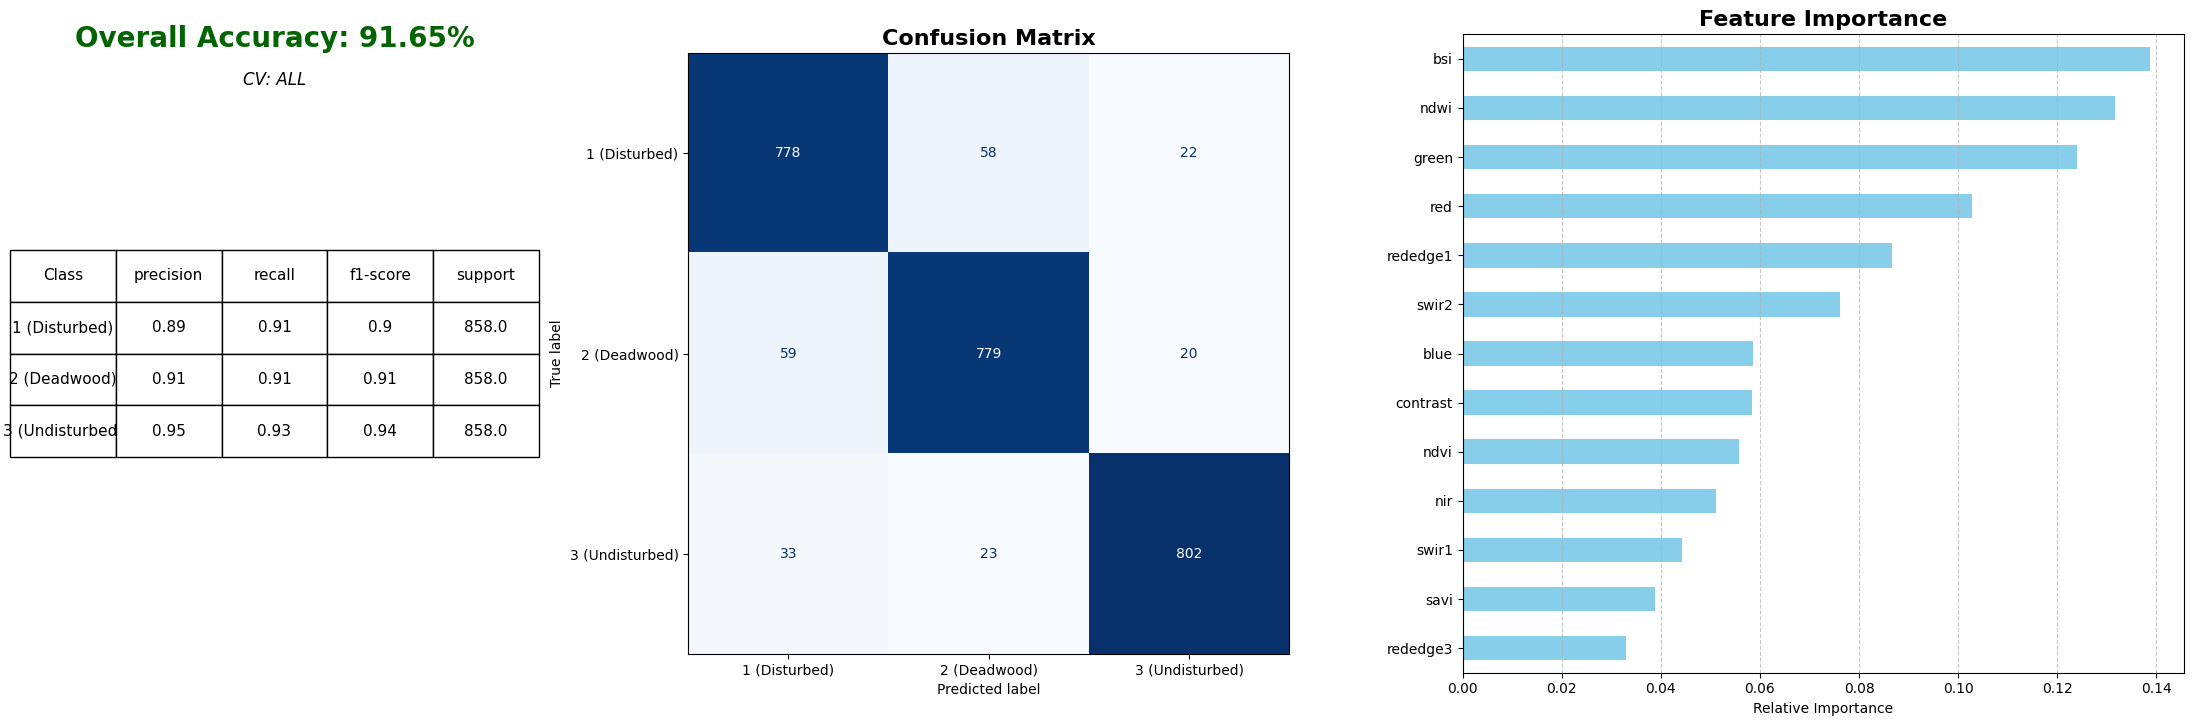

In [15]:
if CROSS == "TRUE":
    # Using the features 'X' and labels 'y' from Cell 7
    # and 'cv_predictions' from Cell 8

    # 1. Get feature importance (from the final fold's model)
    importances = pd.Series(rf.feature_importances_, index=X.columns)

    # 2. Plot the comprehensive dashboard
    fig = plot_cross_model_results(
        y_true=y,
        y_pred=cv_predictions,
        feature_importances=importances,
        train_mode=REGION_TRAIN_MODE,
        val_mode=REGION_VAL_MODE,
        class_names=['Disturbed', 'Deadwood', 'Undisturbed']
    )

    plt.show()
else:
    # Logic for standard (non-cross) validation
    fig = plot_model_results(
        y_true=forestclass_test,
        y_pred=predictions,
        rf_model=rf,
        feature_names=chosen_bands,
        train_mode=REGION_TRAIN_MODE,
        val_mode=REGION_VAL_MODE
    )
    plt.show()

In [16]:
#joblib.dump(rf, r"C:\Users\miles\OneDrive\Dokumente\ROOT\models\rf_s22_s22\rf_s22_s22.joblib")